# HW5 Assigned Problems

In [2]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

## Homework 5 Spring 2026

- **Question 1 (39 points)** For this question, you will use the [polynomial toy data set](../DataSets/DataSets.md#polynomial-toy-data-set) from the course webpage. This is a very simple data set, you will just predict `y` using `X`. We've learned three models in class this week.
  - (A) Polynomial Regression 
  - (B) Step Functions 
  - (C) Cubic splines 

  For each of these, do the following. 
  - (i) Identify the hyperparameter that is relevant to be chosen in that model (degree, number of cuts, etc.).  
  - (ii) Use k-fold CV to find the best choice of that hyperparameter. 
  - (iii) Train the model on all of the data using that chosen hyperparameter. 
  
  Finally, make a plot of the data, along with all three of the learned models plotted on top. What do you notice? Is one a better (or worse choice) than the others? Which would you choose and why? 

- **Question 2 (26 points)**
  - Part A (13 points). I am learning a step function of some data, and I'm using knots $c_1 = 3$ and $c_2 = 7$. 
    - (i) Write equations for each of the basis functions $C_0(X)$, $C_1(X)$, and $C_2(X)$. Sketch the three functions.
    - (ii) If the model learned was 
      
      $$
      f(X) = \beta_0 + \beta_1C_1(X) + \beta_2C_2(X)
      $$
      
      with $\beta_0 = 2$, $\beta_1 = 3$, and $\beta_2 = -1$, sketch the graph learned.
  - Part B (13 points).
    - I am learning a cubic spline of some data with a single knot at $c_1 = 4$. As noted in class and in Sec 7.4.3, we have a basis for learning cubic spline data. *(As a side note, my lectures have knots as $c_1,\cdots,c_K$ and the book uses $\xi_1, \cdots, \xi_K$ but they're the same thing.)* I'm going to build a cubic spline with basis functions 
      - $b_1(X) = X$  
      - $b_2(X) = X^2$  
      - $b_3(X) = X^3$  
      - $b_4(X) =h(x,4)= \begin{cases} (x-4)^3 & x >4 \\ 0 & \text{else} \end{cases}$  
    - Assume the learned model was 
      
      $$ f(X) = 3 + b_1(X) - 2 b_2(X) + 3 b_3(X) - 4b_4(X)$$
    
    - (i) Write the equation for the piecewise polynomial that this function represents. Draw a graph of the function.
    - (ii) What are the requirements for a piecewise polynomial function to be a cubic spline?
    - (iii) Check that your piecewise polynomial from (i) fits these requirements.

### Grading distribution 

(39 + 26 = 65 points)

## Question 1. 


### Generating fake data 

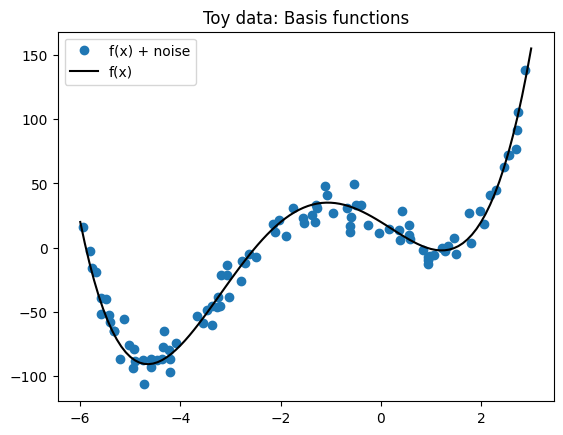

In [3]:
# Set the random seed for reproducibility
np.random.seed(42)

# Define the polynomial
f = lambda x: (x+2)*(x-2)*(x+6)*x+20

# Generate data 
x_data = np.random.uniform(-6, 3, 100)
y_data = f(x_data) + np.random.normal(0, 10, size=x_data.shape)

# Generate data for plotting 
x_plot = np.linspace(-6, 3, 100)
y_plot = f(x_plot)

# Create a DataFrame to store the data
toy_data = pd.DataFrame({'x': x_data, 'y': y_data})

plt.plot(x_data,y_data, 'o', label = 'f(x) + noise')
plt.plot(x_plot, y_plot, 'k', label = 'f(x)')
plt.legend()
plt.title('Toy data: Basis functions')

# plt.savefig('../../DataSets/polynomial-toydata.png')
plt.show()

# toy_data.to_csv('../../DataSets/polynomial-toydata.csv')

### Loading in and doing the problem from scratch to be sure

In [10]:
# First, we're going to do all the data loading we've had for a while for this data set
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/f642ded4bf0e8536ccd7675bb8d41449/polynomial-toydata.csv"
polydf = pd.read_csv(url, index_col=0)
polydf.head()

,x,y
0,-2.629139,-4.940311
1,2.556429,72.467439
2,0.587945,6.763137
3,-0.612074,12.080070
4,-4.595832,-92.688351


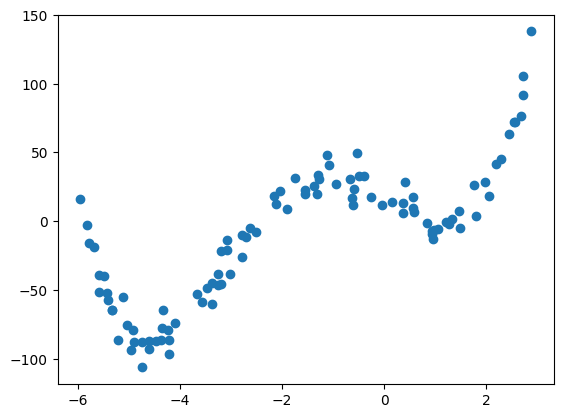

In [11]:
plt.scatter(polydf['x'], polydf['y'])
plt.show()

In [12]:
X = polydf['x'].values.reshape(-1,1)
y = polydf['y']

In [13]:
# Set t_plot for everything 
t_plot = np.linspace(-6, 3, 100).reshape(-1,1)

### (A) Polynomial Regression (13 points)

&#9989; **<font color=red>Do this:</font>** 
- (i) (3 points) Identify the hyperparameter that needs to be selected in the model (e.g., degree, number of cuts, etc.). In this case, the hyperparameter to tune is the degree of the polynomial.

In [23]:
###YOUR CODE HERE###

# Hyperparameter to be selected: Polynomial Degree
# The degree controls the flexibility of the polynomial model.
# Low degree, underfitting
# High degree, overfitting

&#9989; **<font color=red>Do this:</font>**
- (ii) (4 points) Use k-fold CV to find the best choice of that hyperparameter.

In [19]:
##YOUR CODE HERE###

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

X = polydf['x'].values.reshape(-1, 1)
y = polydf['y'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)
degrees = range(1, 11)
cv_mse = []

for d in degrees:
    model = Pipeline([('poly', PolynomialFeatures(degree=d, include_bias=False)), ('lr', LinearRegression())])
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse.append(-scores.mean())

best_degree = degrees[np.argmin(cv_mse)]
best_degree

# 4 is the best choice of that hyperparameter

4

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Train the model on all of the data using that chosen hyperparameter. 

In [20]:
###YOUR CODE HERE###

poly_model = Pipeline([('poly', PolynomialFeatures(degree=best_degree, include_bias=False)), ('lr', LinearRegression())])
poly_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",4
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


#### ✅ Question (A-b): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (A) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

In [21]:
###YOUR ANSWER HERE###

# I already knew the main ideas behind polynomial regression, like what the hyperparameter is, the degree of the polynomial,
# and how cross-validation is used to choose it. For the coding part, I mostly reused and adapted code from past homework assignments
# to help set up k-fold cross-validation and fit the model. I didn’t really look up new methods online.
# I just leaned on my previous class work to make the process faster and cleaner.

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.


In [62]:
### YOUR ANSWER HERE##

# I used ChatGPT to help with Question (A)(iii), where the task was to train the polynomial regression model
# on all of the data using the degree selected from cross-validation.
# These parts were completed using prior knowledge from lecture and earlier homework assignments.
# Identifying the hyperparameter
# Using k-fold cross-validation to select the best degree

#YOUR PROMPTS##

# Skeleton code on how to train a polynomial regression model on all of the data using the degree selected from cross-validation.

##AI OUTPUTS##

# poly_model = Pipeline()
# poly_model.fit(X, y)c
#I used this output as a starting point and integrated it directly into my solution.

### (B) Step Functions (10 points)

&#9989; **<font color=red>Do this:</font>** 
- (i)(3 points) Identify the model hyperparameter (e.g., degree, number of cuts). Here, the hyperparameter to tune is the number of cuts in the step function.

In [24]:
###YOUR CODE HERE###

# Hyperparameter to be selected: number of cuts, intervals
# The number of cuts controls how many step intervals are used.
# Fewer cuts, simpler model and possible underfitting
# More cuts, more flexible model and possible overfitting

&#9989; **<font color=red>Do this:</font>**
- (ii)(4 points) Use k-fold CV to find the best choice of that hyperparameter.

In [27]:
###YOUR CODE HERE###

X = polydf['x'].values
y = polydf['y'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def step_basis(x, n_cuts):
    cuts = np.quantile(x, np.linspace(0, 1, n_cuts + 1))
    return np.column_stack([
        ((x >= cuts[i]) & (x < cuts[i+1])).astype(int)
        for i in range(n_cuts)])

cut_options = range(2, 11)
cv_mse = []

for k in cut_options:
    X_step = step_basis(X, k)
    scores = cross_val_score(LinearRegression(), X_step, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse.append(-scores.mean())

best_cuts = cut_options[np.argmin(cv_mse)]
best_cuts

# 9 is the best choice of that hyperparameter

9

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Train the model on all of the data using that chosen hyperparameter. 

In [28]:
###YOUR CODE HERE###

X_step_full = step_basis(X, best_cuts)
step_model = LinearRegression()
step_model.fit(X_step_full, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### (C) Cubic spline (10 points)


&#9989; **<font color=red>Do this:</font>** 
- (i) (3 points) Identify the model hyperparameter. For a cubic spline, the hyperparameter to tune is the number of knots.

In [29]:
###YOUR CODE HERE###

# Hyperparameter to be selected: number of knots
# The number of knots controls the flexibility of the spline.
# Fewer knots, smoother curve and possible underfitting
# More knots, more flexible curve and possible overfitting

&#9989; **<font color=red>Do this:</font>**
- (ii) (4 points) Use k-fold CV to find the best choice of that hyperparameter.

In [32]:
###YOUR CODE HERE###

from patsy import dmatrix

X = polydf['x'].values
y = polydf['y'].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)
knot_options = range(1, 8)
cv_mse = []

for k in knot_options:
    X_spline = dmatrix(f"bs(x, knots=np.quantile(x, np.linspace(0,1,{k+2})[1:-1]), degree=3, include_intercept=False)", {"x": X}, return_type='dataframe')
    
    scores = cross_val_score(LinearRegression(), X_spline, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse.append(-scores.mean())

best_knots = knot_options[np.argmin(cv_mse)]
best_knots

# 2 is the best choice of that hyperparameter

2

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Train the model on all of the data using that chosen hyperparameter. 

In [33]:
###YOUR CODE HERE###

X = polydf['x'].values
y = polydf['y'].values
X_spline_full = dmatrix(f"bs(x, knots=np.quantile(x, np.linspace(0,1,{best_knots+2})[1:-1]), degree=3, include_intercept=False)", {"x": X}, return_type='dataframe')

spline_model = LinearRegression()
spline_model.fit(X_spline_full, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


&#9989; **<font color=red>Do this:</font>** Show all of them together (3 points)

Create a plot of the data with all three fitted models overlaid. Describe your observations. Does one model provide a better or worse fit than the others? Which model would you select, and why?



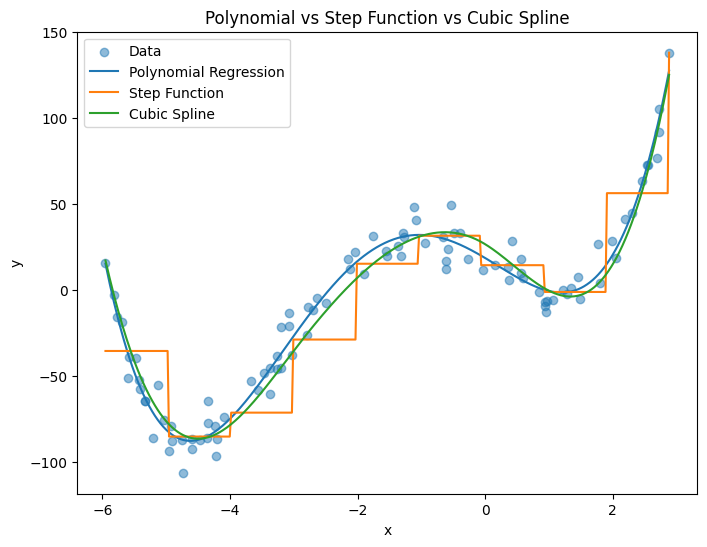

In [36]:
###YOUR CODE AND ANSWER HERE###

x_grid = np.linspace(polydf['x'].min(), polydf['x'].max(), 400)
x_grid_2d = x_grid.reshape(-1, 1)
y_poly = poly_model.predict(x_grid_2d)

X_step_grid = step_basis(x_grid, best_cuts)
y_step = step_model.predict(X_step_grid)

X_spline_grid = dmatrix(f"bs(x, knots=np.quantile(x, np.linspace(0,1,{best_knots+2})[1:-1]), degree=3, include_intercept=False)", {"x": x_grid}, return_type='dataframe')
y_spline = spline_model.predict(X_spline_grid)

plt.figure(figsize=(8,6))
plt.scatter(polydf['x'], polydf['y'], alpha=0.5, label="Data")
plt.plot(x_grid, y_poly, label="Polynomial Regression")
plt.plot(x_grid, y_step, label="Step Function")
plt.plot(x_grid, y_spline, label="Cubic Spline")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial vs Step Function vs Cubic Spline")
plt.legend()
plt.show()

# The step function produces a piecewise-constant fit that looks rough and less natural for this smooth underlying relationship.
# Polynomial regression gives a smooth curve but can behave poorly near the boundaries.
# The cubic spline provides a smooth fit while remaining flexible locally and does not show extreme behavior at the edges.
# I would choose the cubic spline, because it balances flexibility and smoothness well and best matches the apparent structure of the data without overfitting.

&#9989; **<font color=red>Do this:</font>** Show all of them together (3 points)

Based on the above observations. Does one model provide a better or worse fit than the others? Which model would you select, and why?


In [38]:
###YOUR ANSWER HERE###

# From the plot, the step function looks like the worst fit because it jumps between flat levels and doesn’t follow the smooth pattern in the data very well.
# The polynomial regression does a better job and gives a smooth curve, but it can act a little strange near the ends of the data range.
# The cubic spline fits the data the best overall — it is smooth and flexible, and it follows the shape of the data without being too wiggly.
# I would choose the cubic spline because it captures the trend in the data well while staying stable and not overfitting.

## Q2: 

### Part A (13 points). 
&#9989; **<font color=red>Do this:</font>** I am learning a step function of some data, and I'm using knots $c_1 = 3$ and $c_2 = 7$. 
- (i) (5 points) Write equations for each of the basis functions $C_0(X)$, $C_1(X)$, and $C_2(X)$. Sketch the three functions.



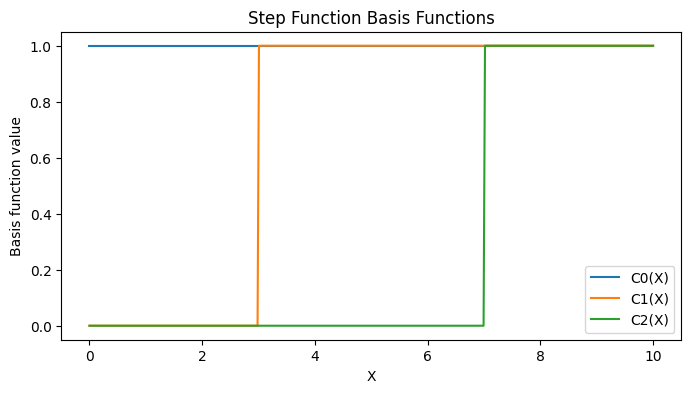

In [68]:
###YOUR CODE HERE##

c1, c2 = 3, 7

def C0(x):
    return np.ones_like(x)

def C1(x):
    return (x >= c1).astype(int)

def C2(x):
    return (x >= c2).astype(int)

x_grid = np.linspace(0, 10, 400)

y_C0 = C0(x_grid)
y_C1 = C1(x_grid)
y_C2 = C2(x_grid)

plt.figure(figsize=(8,4))
plt.plot(x_grid, y_C0, label="C0(X)")
plt.plot(x_grid, y_C1, label="C1(X)")
plt.plot(x_grid, y_C2, label="C2(X)")
plt.xlabel("X")
plt.ylabel("Basis function value")
plt.title("Step Function Basis Functions")
plt.legend()
plt.show()

# C0(x) = 1
# C1(x) = 1(x >= 3)
# C2(x) = 1(x >= 7)

# C0 is a straight constant line at basis function value 1.
# C1 starts at constant basis function value 0 and then jumps up to 1 when X reaches 3. Then line stays constant at 1
# C2 starts at constant basis function value 0 and then jumps to 1 when X reaches 7. Then line stays constant at 1

#### ✅ Question (i-b): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (i) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

In [40]:
###YOUR ANSWER HERE###

# I already understood the main concepts for all three models:
# Polynomial regression: the role of polynomial degree and why overfitting/underfitting happens.
# Step functions: how the number of cuts controls model flexibility.
# Cubic splines: how knots control local flexibility and smoothness.
# For the coding part, especially fitting the models, using k-fold CV, and creating the plots,
# I relied on past homework assignments and a little help from ChatGPT to write clean code for training and plotting the models.

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [41]:
### YOUR ANSWER HERE##

# I used ChatGPT to help with coding Question 1(iii) for polynomial regression, step functions, and cubic splines,
# particularly for training the models on all data after selecting the best hyperparameter and for plotting them together.

#YOUR PROMPTS##

# Train the polynomial regression / step function / cubic spline model on all data using the chosen hyperparameter and plot it.

##AI OUTPUTS##

# plt.figure(figsize=(8,6))
# plt.scatter(polydf['x'], polydf['y'], alpha=0.5, label="Data")
# plt.plot(x_grid, y_poly, label="Polynomial Regression")
# plt.plot(x_grid, y_step, label="Step Function")
# plt.plot(x_grid, y_spline, label="Cubic Spline")

&#9989; **<font color=red>Do this:</font>**
- (ii) (5 points) If the model learned was 
    
    $$
    f(X) = \beta_0 + \beta_1C_1(X) + \beta_2C_2(X)
    $$
    
    with $\beta_0 = 2$, $\beta_1 = 3$, and $\beta_2 = -1$, sketch the graph learned.
    

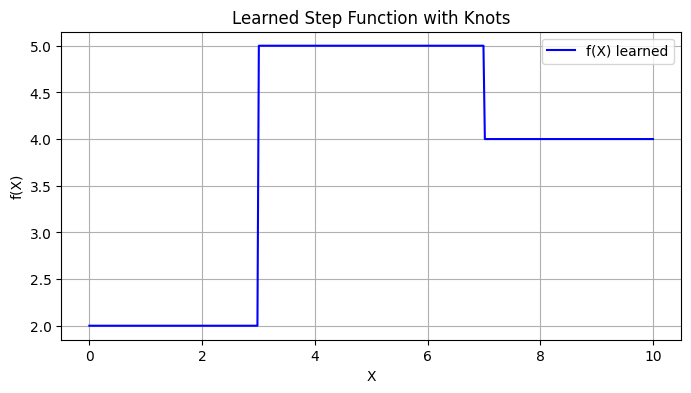

In [64]:
###YOUR CODE HERE###

beta0, beta1, beta2 = 2, 3, -1

def f_learned(x):
    return beta0 + beta1*C1(x) + beta2*C2(x)

x_grid = np.linspace(0, 10, 400)
y_grid = f_learned(x_grid)

plt.figure(figsize=(8,4))
plt.plot(x_grid, y_grid, label="f(X) learned", color='blue')
plt.xlabel("X")
plt.ylabel("f(X)")
plt.title("Learned Step Function with Knots")
plt.grid(True)
plt.legend()
plt.show()

# The function starts at a value of 2 for X < 3. At X = 3, it jumps up to 5 and remains constant at 5 for 3 <= X < 7. At X = 7,
# it drops to 4 and then stays constant at 4 for X >= 7.

### Part B (13 points).
- I am learning a cubic spline of some data with a single knot at $c_1 = 4$. As noted in class and in Sec 7.4.3, we have a basis for learning cubic spline data. *(As a side note, my lectures have knots as $c_1,\cdots,c_K$ and the book uses $\xi_1, \cdots, \xi_K$ but they're the same thing.)* I'm going to build a cubic spline with basis functions 
    - $b_1(X) = X$  
    - $b_2(X) = X^2$  
    - $b_3(X) = X^3$  
    - $b_4(X) =h(x,4)= \begin{cases} (x-4)^3 & x >4 \\ 0 & \text{else} \end{cases}$  
- Assume the learned model was 
    
    $$ f(X) = 3 + b_1(X) - 2 b_2(X) + 3 b_3(X) - 4b_4(X)$$

- (i) Write the equation for the piecewise polynomial that this function represents. Draw a graph of the function.
- (ii) What are the requirements for a piecewise polynomial function to be a cubic spline?
- (iii) Check that your piecewise polynomial from (i) fits these requirements.


&#9989; **<font color=red>Do this:</font>**
- (i) (3 points) Write the equation for the piecewise polynomial that this function represents. Draw a graph of the function.

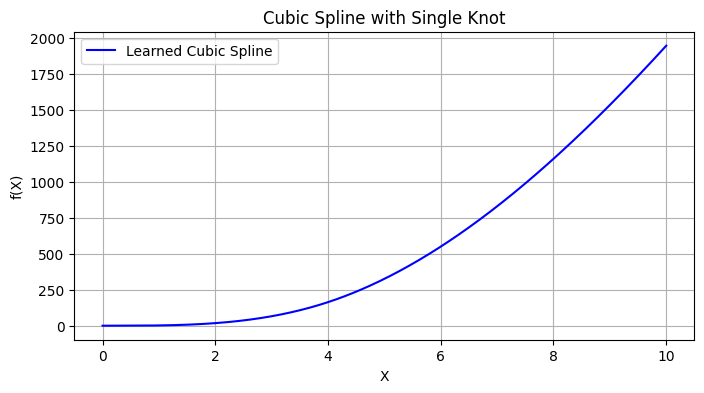

In [67]:
###YOUR CODE HERE###

def b1(x):
    return x

def b2(x):
    return x**2

def b3(x):
    return x**3

def b4(x):
    return np.where(x > 4, (x-4)**3, 0)

def f_spline(x):
    return 3 + b1(x) - 2*b2(x) + 3*b3(x) - 4*b4(x)

y_grid = f_spline(x_grid)

plt.figure(figsize=(8,4))
plt.plot(x_grid, y_grid, label="Learned Cubic Spline", color='blue')
plt.xlabel("X")
plt.ylabel("f(X)")
plt.title("Cubic Spline with Single Knot")
plt.grid(True)
plt.legend()
plt.show()

# f(X) = {3 + X - 2X^2 +3X^3, X <= 4
# f(X) = {3 + X - 2X^2 + 3X^3 - 4(X - 4)^3, X > 4

# This function is a cubic spline with a knot at X = 4. For X less than or equal to 4, it follows a cubic polynomial. For X > 4, an additional cubic term 
# −4(X − 4)^3 is introduced, which modifies the curve while maintaining smoothness at the knot.

&#9989; **<font color=red>Do this:</font>**
- (ii) (4 points) What are the requirements for a piecewise polynomial function to be a cubic spline?


###YOUR ANSWER HERE##

A piecewise polynomial function is a cubic spline if
* Each segment between knots is a cubic polynomial.
* The function is continuous at the knots.
* The first derivative $f'(X)$ is continuous at the knots.
* The second derivative $f''(X)$ is continuous at the knots.

These conditions makes a smooth curve with no jumps or kinks.

#### ✅ Question (ii): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (ii) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

In [59]:
###YOUR ANSWER HERE###

# For this part, I already understood the concepts behind cubic splines, including how the basis functions work,
# how knots affect the piecewise polynomial, and the requirements for a cubic spline,
# continuity of the function and its first two derivatives.
# I only needed a little help with the Python coding to implement and plot the spline function, which I used to visualize the learned model.

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [69]:
### YOUR ANSWER HERE##

# I used ChatGPT to help with the coding for plotting the cubic spline and implementing the piecewise polynomial for Question 2 Part B.
# completed the conceptual understanding, including writing the piecewise polynomial equation and checking the spline requirements,
# using my prior knowledge from lecture and past homework.

# YOUR PROMPTS

# Write Python code using sklearn Pipeline to train a polynomial regression model with a given degree and fit it to X and y.

# AI OUTPUTS
# poly_model = Pipeline([
#    ('poly', PolynomialFeatures(degree=d, include_bias=False)),
#    ('lr', LinearRegression())])
# poly_model.fit(X, y)

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Check that your piecewise polynomial from (i) fits these requirements.

In [60]:
###YOUR ANSERE HERE###

def f_left(x):
    return 3 + x - 2*x**2 + 3*x**3

def f_right(x):
    return 3 + x - 2*x**2 + 3*x**3 - 4*(x-4)**3

def f_left_prime(x):
    return 1 - 4*x + 9*x**2

def f_right_prime(x):
    return 1 - 4*x + 9*x**2 - 12*(x-4)**2

def f_left_double_prime(x):
    return -4 + 18*x

def f_right_double_prime(x):
    return -4 + 18*x - 24*(x-4)

x_knot = 4
print("f(4-):", f_left(x_knot), "f(4+):", f_right(x_knot))
print("f'(4-):", f_left_prime(x_knot), "f'(4+):", f_right_prime(x_knot))
print("f''(4-):", f_left_double_prime(x_knot), "f''(4+):", f_right_double_prime(x_knot))

f(4-): 167 f(4+): 167
f'(4-): 129 f'(4+): 129
f''(4-): 68 f''(4+): 68
